In [1]:
!git clone -b rogelio_resnet50_modeling  https://github.com/seanmcgowanx/coral-reef-classification.git

Cloning into 'coral-reef-classification'...
remote: Enumerating objects: 372, done.
remote: Counting objects: 100% (150/150), done.
remote: Compressing objects: 100% (87/87), done.
remote: Total 372 (delta 115), reused 63 (delta 63), pack-reused 222 (from 2)
Receiving objects: 100% (372/372), 77.99 MiB | 15.92 MiB/s, done.
Resolving deltas: 100% (162/162), done.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install -q -r /content/coral-reef-classification/requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.5/14.5 MB 152.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 10.6 MB/s eta 0:00:00


# ResNet-50

In [4]:
import sys
import os

def in_colab():
    return "COLAB_GPU" in os.environ or "google.colab" in sys.modules

if in_colab():
    # Running in Google Colab
    repo_path = "/content/coral-reef-classification"
    data_path = "/content/coral-reef-classification/data/processed"

    # Set working directory to the repo root
    os.chdir(repo_path)

else:
    # Running locally in VS Code
    repo_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
    data_path = os.path.abspath(os.path.join(repo_path, "data", "processed"))

    # Add repo root to Python path
    if repo_path not in sys.path:
        sys.path.append(repo_path)

    # Set working directory to the repo root
    os.chdir(repo_path)

print("Using repo path:", repo_path)
print("Using data path:", data_path)
print("CWD:", os.getcwd())

Using repo path: /content/coral-reef-classification
Using data path: /content/coral-reef-classification/data/processed
CWD: /content/coral-reef-classification


In [5]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.models import resnet50, ResNet50_Weights
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from sklearn.metrics import (
    auc,
    roc_curve,
    f1_score,
    classification_report,
    roc_auc_score,
    multilabel_confusion_matrix,
    precision_recall_curve,
    average_precision_score
)

### Data Augmentations

In [6]:
# ImageNet normalization
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_transform = T.Compose([
    # Geometric transforms
    T.RandomResizedCrop(224, scale=(0.7, 1.0), ratio=(0.9, 1.1)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),

    # Photometric transforms
    T.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    # Mild blur (simulates turbidity & motion)
    T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),

    # Convert & Normalize
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Define test/validation transformations
test_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

### Build the CoralReefDataset Class

In [7]:
import boto3
from botocore.config import Config
from botocore import UNSIGNED
import io
from PIL import Image

# Anonymous S3 client for MERMAID public bucket
s3 = boto3.client(
    "s3",
    region_name="us-east-1",
    config=Config(signature_version=UNSIGNED)
)

def get_image_s3(image_id: str, thumbnail: bool = False,
                 bucket: str = "coral-reef-training"):
    """
    Streams a MERMAID image directly from the public S3 bucket.

    Returns a PIL.Image in RGB mode.
    """
    key = f"mermaid/{image_id}_thumbnail.png" if thumbnail else f"mermaid/{image_id}.png"

    try:
        resp = s3.get_object(Bucket=bucket, Key=key)
        img = Image.open(io.BytesIO(resp["Body"].read())).convert("RGB")
        return img
    except Exception as e:
        raise RuntimeError(f"Could not load image {image_id} from S3. Key tried: {key}. Error: {e}")

In [8]:
class CoralReefDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

        # The first column must be image_id
        self.image_ids = self.df["image_id"].tolist()

        # All columns after image_id are labels
        self.label_cols = self.df.columns[1:].tolist()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]

        # Load from Mermaid public S3 bucket
        image = get_image_s3(image_id)

        if self.transform:
            image = self.transform(image)

        labels = torch.tensor(
            self.df.loc[idx, self.label_cols].values.astype("float32")
        )

        return image, labels


### Create Train, Validation, Test Datasets

In [9]:
train_csv = os.path.join(data_path, "final_labels_train.csv")
test_csv = os.path.join(data_path, "final_labels_test.csv")

# Load CSVs
df_train_full = pd.read_csv(train_csv)
df_test = pd.read_csv(test_csv)

# Drop metadata columns if present
meta_cols = ["region_name"]
df_train_full = df_train_full.drop(columns=[c for c in meta_cols if c in df_train_full.columns])
df_test = df_test.drop(columns=[c for c in meta_cols if c in df_test.columns])

# Label columns (starts at column 1 because col 0 is image_id)
class_names = df_train_full.columns[1:]
num_classes = len(class_names)

# Extract label matrix for stratified split
y = df_train_full[class_names].values

msss = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.05,
    random_state=42
)

for train_idx, val_idx in msss.split(df_train_full, y):
    train_df = df_train_full.iloc[train_idx].reset_index(drop=True)
    val_df = df_train_full.iloc[val_idx].reset_index(drop=True)

train_dataset = CoralReefDataset(train_df, transform=train_transform)
val_dataset = CoralReefDataset(val_df, transform=test_transform)
test_dataset = CoralReefDataset(df_test, transform=test_transform)

### Create DataLoaders

In [10]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

### Build and configure the ResNet-50 model



In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load ImageNet-pretrained weights
weights = ResNet50_Weights.IMAGENET1K_V1
model = resnet50(weights=weights)

# Replace the fc head with dropout and linear to improve generalization
num_features = model.fc.in_features
num_classes = len(class_names)
model.fc = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(num_features, num_classes)
)

# Move model to device
model = model.to(device)

print("\nModel successfully built:")
print(model)
print(f"\nNumber of trainable parameters: "
      f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 242MB/s]



Model successfully built:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kern

### Loss Function and Optimizer

In [12]:
# Loss function for multi-label classification
criterion = nn.BCEWithLogitsLoss()

# Freeze everything except the head
for name, param in model.named_parameters():
    if not name.startswith("fc"):
        param.requires_grad = False

# Stage 1 optimizer (head only, backbone frozen initially)
optimizer_stage1 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-5,
    weight_decay=1e-5
)

# Learning rate scheduler for Stage 1
scheduler_stage1 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_stage1,
    T_max=5
)

### Stage 1 Training



In [13]:
def validate(model, loader, criterion, device):
    # Runs one validation epoch

    model.eval()

    total_loss = 0.0
    n_batches = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            n_batches += 1

    # Compute mean over all batches
    val_loss = total_loss / n_batches

    return val_loss

In [14]:
def train_stage_1(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    num_epochs=5,
    ckpt_path="resnet50_stage1_best.pth"
):
    history = {
        "train_loss": [],
        "val_loss": []
    }

    best_val_loss = 100.0

    print("\n===== Starting Stage 1 Training =====\n")

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = 0.0
        n_batches    = 0

        # Train loop
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            logits = model(images)
            loss = criterion(logits, labels)

            loss.backward()

            # Stability for small head
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)

            optimizer.step()

            running_loss += loss.item()
            n_batches    += 1

        train_loss = running_loss / n_batches

        val_loss = validate(model, val_loader, criterion, device)

        if scheduler is not None:
            scheduler.step()

        print(
            f"Epoch [{epoch}/{num_epochs}]\n"
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}\n"
        )

        # Save best model based on val f1 score
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "scheduler_state_dict": scheduler.state_dict(),
                },
                ckpt_path
            )
            print(f"Saved best Stage 1 model (Val loss: {best_val_loss:.4f})\n")

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

    return history

### Run Stage 1 Training

In [ ]:
history_stage1 = train_stage_1(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_stage1,
    scheduler=scheduler_stage1,
    device=device,
    num_epochs=5,
    ckpt_path="resnet50_stage1_best.pth"
)


===== Starting Stage 1 Training =====

Epoch [1/5]
Train Loss: 0.5188 | Val Loss: 0.4912

Saved best Stage 1 model (Val loss: 0.4912)

Epoch [2/5]
Train Loss: 0.4789 | Val Loss: 0.4786

Saved best Stage 1 model (Val loss: 0.4786)

Epoch [3/5]
Train Loss: 0.4692 | Val Loss: 0.4706

Saved best Stage 1 model (Val loss: 0.4706)

Epoch [4/5]
Train Loss: 0.4627 | Val Loss: 0.4658

Saved best Stage 1 model (Val loss: 0.4658)

Epoch [5/5]
Train Loss: 0.4597 | Val Loss: 0.4660



### Plot Stage 1 Learning Curves

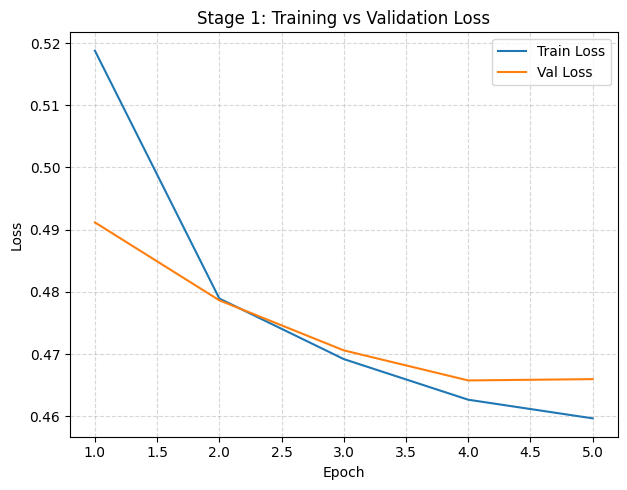

In [ ]:
epochs = range(1, len(history_stage1["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

# Loss Curve
plt.subplot(1, 2, 1)
plt.plot(epochs, history_stage1["train_loss"], label="Train Loss")
plt.plot(epochs, history_stage1["val_loss"], label="Val Loss")
plt.title("Stage 1: Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

### Stage 2 Training

In [15]:
def unfreeze_stage2(model, freeze_until="layer2"):
    # Unfreezes layers deeper than 'freeze_until'

    freeze_map = {
        "conv1": [],
        "layer1": ["layer1", "layer2", "layer3", "layer4"],
        "layer2": ["layer2", "layer3", "layer4"],
        "layer3": ["layer3", "layer4"],
        "layer4": ["layer4"],
    }

    to_unfreeze = freeze_map.get(freeze_until, ["layer3", "layer4"])

    # Freeze everything by default
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze desired deeper layers
    for name, module in model.named_children():
        if name in to_unfreeze:
            for param in module.parameters():
                param.requires_grad = True

    # Ensure classifier is unfrozen
    for param in model.fc.parameters():
        param.requires_grad = True

    print(f"\nStage 2 unfreezing complete. Layers unfrozen: {to_unfreeze}")

In [16]:
def train_stage_2(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    patience=3,
    num_epochs=10,
    ckpt_path="resnet50_stage2_best.pth"
):
    history = {
        "train_loss": [],
        "val_loss": []
    }

    best_val_loss = 100.0
    best_state = None
    patience_counter = 0

    print("\n===== Starting Stage 2 Fine-Tuning =====\n")

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = 0.0
        n_batches = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)

            loss.backward()

            # stability improvement
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)

            optimizer.step()

            running_loss += loss.item()
            n_batches += 1

        train_loss = running_loss / n_batches

        val_loss = validate(model, val_loader, criterion, device)

        if scheduler is not None:
            scheduler.step()

        print(
            f"Epoch [{epoch}/{num_epochs}]\n"
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}\n"
        )

        # Early stopping and save best model based on F1
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "scheduler_state_dict": scheduler.state_dict()
                },
                ckpt_path
            )
            best_state = model.state_dict()
            patience_counter = 0
            print(f"New best Stage 2 model saved! Val Loss = {best_val_loss:.4f}\n")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

    # Restore best model
    if best_state is not None:
        model.load_state_dict(best_state)

    return history

### Update model

In [17]:
old_fc = model.fc[1]
model.fc = nn.Sequential(
    nn.Dropout(0.3), # increased dropout to reduce overfitting
    old_fc
)

model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

### Set Stage 2 optimizer

In [18]:
# Lower LR for fine-tuning
optimizer_stage2 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5,
    weight_decay=1e-5
)

scheduler_stage2 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_stage2,
    T_max=10
)

### Unfreeze remaining layers and Run Stage 2 Traninig

In [19]:
# Unfreeze deeper layers
unfreeze_stage2(model, freeze_until="layer2")


Stage 2 unfreezing complete. Layers unfrozen: ['layer2', 'layer3', 'layer4']


In [ ]:
# Start Stage 2 fine-tuning
history_stage2 = train_stage_2(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_stage2,
    scheduler=scheduler_stage2,
    device=device,
    num_epochs=10,
    patience=2,
    ckpt_path="resnet50_stage2_best.pth"
)


Stage 2 unfreezing complete. Layers unfrozen: ['layer2', 'layer3', 'layer4']

===== Starting Stage 2 Fine-Tuning =====

Epoch [1/10]
Train Loss: 0.4595 | Val Loss: 0.4630

New best Stage 2 model saved! Val Loss = 0.4630

Epoch [2/10]
Train Loss: 0.4590 | Val Loss: 0.4611

New best Stage 2 model saved! Val Loss = 0.4611

Epoch [3/10]
Train Loss: 0.4562 | Val Loss: 0.4598

New best Stage 2 model saved! Val Loss = 0.4598

Epoch [4/10]
Train Loss: 0.4549 | Val Loss: 0.4587

New best Stage 2 model saved! Val Loss = 0.4587

Epoch [5/10]
Train Loss: 0.4556 | Val Loss: 0.4584

New best Stage 2 model saved! Val Loss = 0.4584

Epoch [6/10]
Train Loss: 0.4530 | Val Loss: 0.4556

New best Stage 2 model saved! Val Loss = 0.4556

Epoch [7/10]
Train Loss: 0.4525 | Val Loss: 0.4560

Epoch [8/10]
Train Loss: 0.4508 | Val Loss: 0.4552

New best Stage 2 model saved! Val Loss = 0.4552

Epoch [9/10]
Train Loss: 0.4518 | Val Loss: 0.4560

Epoch [10/10]
Train Loss: 0.4512 | Val Loss: 0.4566

Early stopping 

In [ ]:
save_path = "/content/drive/MyDrive/resnet50_model/stage_training/"
os.makedirs(save_path, exist_ok=True)

# Save model weights
torch.save(model.state_dict(), save_path + "resnet50_stage2_best.pth")

print("Saved model to:", save_path)

Saved model to: /content/drive/MyDrive/resnet50_model/stage_training/


### Plot Stage 2 Learning Curve

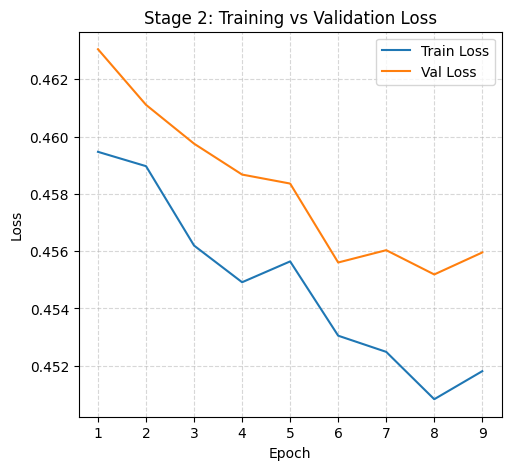

In [ ]:
epochs = range(1, len(history_stage2["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

# Loss Curve
plt.subplot(1, 2, 1)
plt.plot(epochs, history_stage2["train_loss"], label="Train Loss")
plt.plot(epochs, history_stage2["val_loss"], label="Val Loss")
plt.title("Stage 2: Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

In [20]:
stage2_path = "/content/drive/MyDrive/resnet50_model/stage_training/resnet50_stage2_best.pth"

# Load state_dict from file
state_dict = torch.load(stage2_path, map_location=device)

# Load into model (strict=True since architecture did not change after saving)
model.load_state_dict(state_dict, strict=True)

model.to(device)

print("Loaded Stage 2 model from:", stage2_path)

Loaded Stage 2 model from: /content/drive/MyDrive/resnet50_model/stage_training/resnet50_stage2_best.pth


### Evaluate Model & Metrics

In [21]:
def collect_probs_and_targets(model, data_loader, device):
    """
    Run model in eval mode and collect:
        - predicted probabilities (probs)
        - ground truth labels (targets)
    Returns numpy arrays
    """
    model.eval()
    probs_list = []
    labels_list = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            probs = torch.sigmoid(logits)

            probs_list.append(probs.cpu().numpy())
            labels_list.append(labels.cpu().numpy())

    probs = np.vstack(probs_list)
    targets = np.vstack(labels_list)

    return probs, targets

In [23]:
def optimize_thresholds(probs, targets, class_names):
    """
    Find optimal decision thresholds for each label to maximize F1 score.

    For each label, sweeps through 101 threshold values from 0 to 1 and selects
    the threshold that produces the highest F1 score. This is necessary because
    multi-label classification requires per-label decision thresholds rather than
    a single global threshold.
    """
    thresholds = []
    per_label_scores = []

    for i, name in enumerate(class_names):
        best_f1 = -1
        best_t = 0.5

        # Sweep thresholds
        for t in np.linspace(0, 1, 101):
            preds = (probs[:, i] > t).astype(int)
            f1 = f1_score(targets[:, i], preds, zero_division=0)

            if f1 > best_f1:
                best_f1 = f1
                best_t = t

        thresholds.append(best_t)
        per_label_scores.append(best_f1)

        print(f"{name} - Threshold: {best_t:.3f} | F1: {best_f1:.3f}")

    return np.array(thresholds), np.array(per_label_scores)

In [38]:
def predict_with_thresholds(probs, thresholds):
    # Compute predictions using per-class thresholds
    thresholds = np.array(thresholds).reshape(1, -1)
    return (probs > thresholds).astype(int)

In [39]:
def generate_classification_report(targets, preds, thresholds, class_names):
    # Prints a text classification report
    print("\n===== CLASSIFICATION REPORT – OPTIMAL THRESHOLDS =====\n")
    print(classification_report(
        targets,
        preds,
        target_names=class_names,
        zero_division=0
    ))

In [40]:
def compute_auc_metrics(probs, targets, class_names):
    roc_auc = {}
    pr_auc = {}

    for i, cls in enumerate(class_names):
        try:
            roc_auc[cls] = roc_auc_score(targets[:, i], probs[:, i])
        except ValueError:
            roc_auc[cls] = np.nan

        pr_auc[cls] = average_precision_score(targets[:, i], probs[:, i])

    return roc_auc, pr_auc

### Performance Analysis

In [22]:
# Generate Validation and Test (Predictions & Targets)
val_probs, val_targets = collect_probs_and_targets(model, val_loader, device)
test_probs, test_targets = collect_probs_and_targets(model, test_loader, device)

In [24]:
# Compute Optimal Decision Thresholds
optimized_thresholds, val_f1s = optimize_thresholds(val_probs, val_targets, class_names)

Macroalgae - Threshold: 0.740 | F1: 0.907
Rubble - Threshold: 0.510 | F1: 0.848
Crustose coralline algae - Threshold: 0.430 | F1: 0.762
Bare substrate - Threshold: 0.390 | F1: 0.683
Sand - Threshold: 0.420 | F1: 0.813
Turf algae - Threshold: 0.230 | F1: 0.481
Porites - Threshold: 0.380 | F1: 0.621
Hard coral - Threshold: 0.410 | F1: 0.686
Soft coral - Threshold: 0.200 | F1: 0.342
Acropora - Threshold: 0.150 | F1: 0.520
Tape - Threshold: 0.200 | F1: 0.532
Pocillopora - Threshold: 0.100 | F1: 0.267
Dead coral - Threshold: 0.140 | F1: 0.400
Montipora - Threshold: 0.040 | F1: 0.141
Cyanobacteria - Threshold: 0.100 | F1: 0.190
Sponge - Threshold: 0.070 | F1: 0.261


In [41]:
# Generate predictions with thresholds
preds = predict_with_thresholds(test_probs, optimized_thresholds)

In [42]:
# Generate Classification Report
report_results = generate_classification_report(
    test_targets,
    preds,
    optimized_thresholds,
    class_names
)


===== CLASSIFICATION REPORT – OPTIMAL THRESHOLDS =====

                          precision    recall  f1-score   support

              Macroalgae       0.43      0.68      0.52       885
                  Rubble       0.38      0.97      0.55       841
Crustose coralline algae       0.74      0.55      0.63      1433
          Bare substrate       0.63      0.60      0.62      1265
                    Sand       0.46      0.88      0.61       816
              Turf algae       0.58      0.76      0.66      1328
                 Porites       0.30      0.30      0.30       590
              Hard coral       0.15      0.66      0.25       334
              Soft coral       0.45      0.56      0.50       870
                Acropora       0.48      0.60      0.53       720
                    Tape       0.06      0.13      0.08       136
             Pocillopora       0.19      0.19      0.19       320
              Dead coral       0.05      0.12      0.07       196
               Mon

In [44]:
# Compute AUC metrics
roc_auc, pr_auc = compute_auc_metrics(test_probs, test_targets, class_names)

print("\n===== ROC-AUC Per Class =====")
for cls in class_names:
    print(f"{cls:20s}: {roc_auc[cls]:.4f}")

print("\n===== PR-AUC (Average Precision) Per Class =====")
for cls in class_names:
    print(f"{cls:20s}: {pr_auc[cls]:.4f}")


===== ROC-AUC Per Class =====
Macroalgae          : 0.5335
Rubble              : 0.4989
Crustose coralline algae: 0.6158
Bare substrate      : 0.5840
Sand                : 0.7098
Turf algae          : 0.3914
Porites             : 0.5596
Hard coral          : 0.4902
Soft coral          : 0.5601
Acropora            : 0.6941
Tape                : 0.5774
Pocillopora         : 0.5668
Dead coral          : 0.3876
Montipora           : 0.5494
Cyanobacteria       : 0.5358
Sponge              : 0.5069

===== PR-AUC (Average Precision) Per Class =====
Macroalgae          : 0.4236
Rubble              : 0.3970
Crustose coralline algae: 0.7546
Bare substrate      : 0.6046
Sand                : 0.5281
Turf algae          : 0.5294
Porites             : 0.3114
Hard coral          : 0.1468
Soft coral          : 0.4398
Acropora            : 0.5902
Tape                : 0.0689
Pocillopora         : 0.1753
Dead coral          : 0.0693
Montipora           : 0.0889
Cyanobacteria       : 0.0760
Sponge      

### Plots

### Confusion Matricies

In [71]:
def plot_confusion_grid(preds, targets, class_names):
    cm = multilabel_confusion_matrix(targets, preds)

    n_classes = len(class_names)
    cols = 4
    rows = int(n_classes/cols)

    fig, axes = plt.subplots(rows, cols, figsize=(14, 14))
    axes = axes.flatten()

    for i, cls in enumerate(class_names):
        tn, fp, fn, tp = cm[i].ravel()

        ax = axes[i]
        matrix = np.array([[tn, fp], [fn, tp]])

        im = ax.imshow(matrix, cmap="Blues")
        ax.set_title(f"{cls}")
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(["0", "1"])
        ax.set_yticklabels(["0", "1"])
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

        for (j, k), val in np.ndenumerate(matrix):
            ax.text(k, j, f"{val}", ha="center", va="center", color="black")

    plt.tight_layout()
    plt.show()

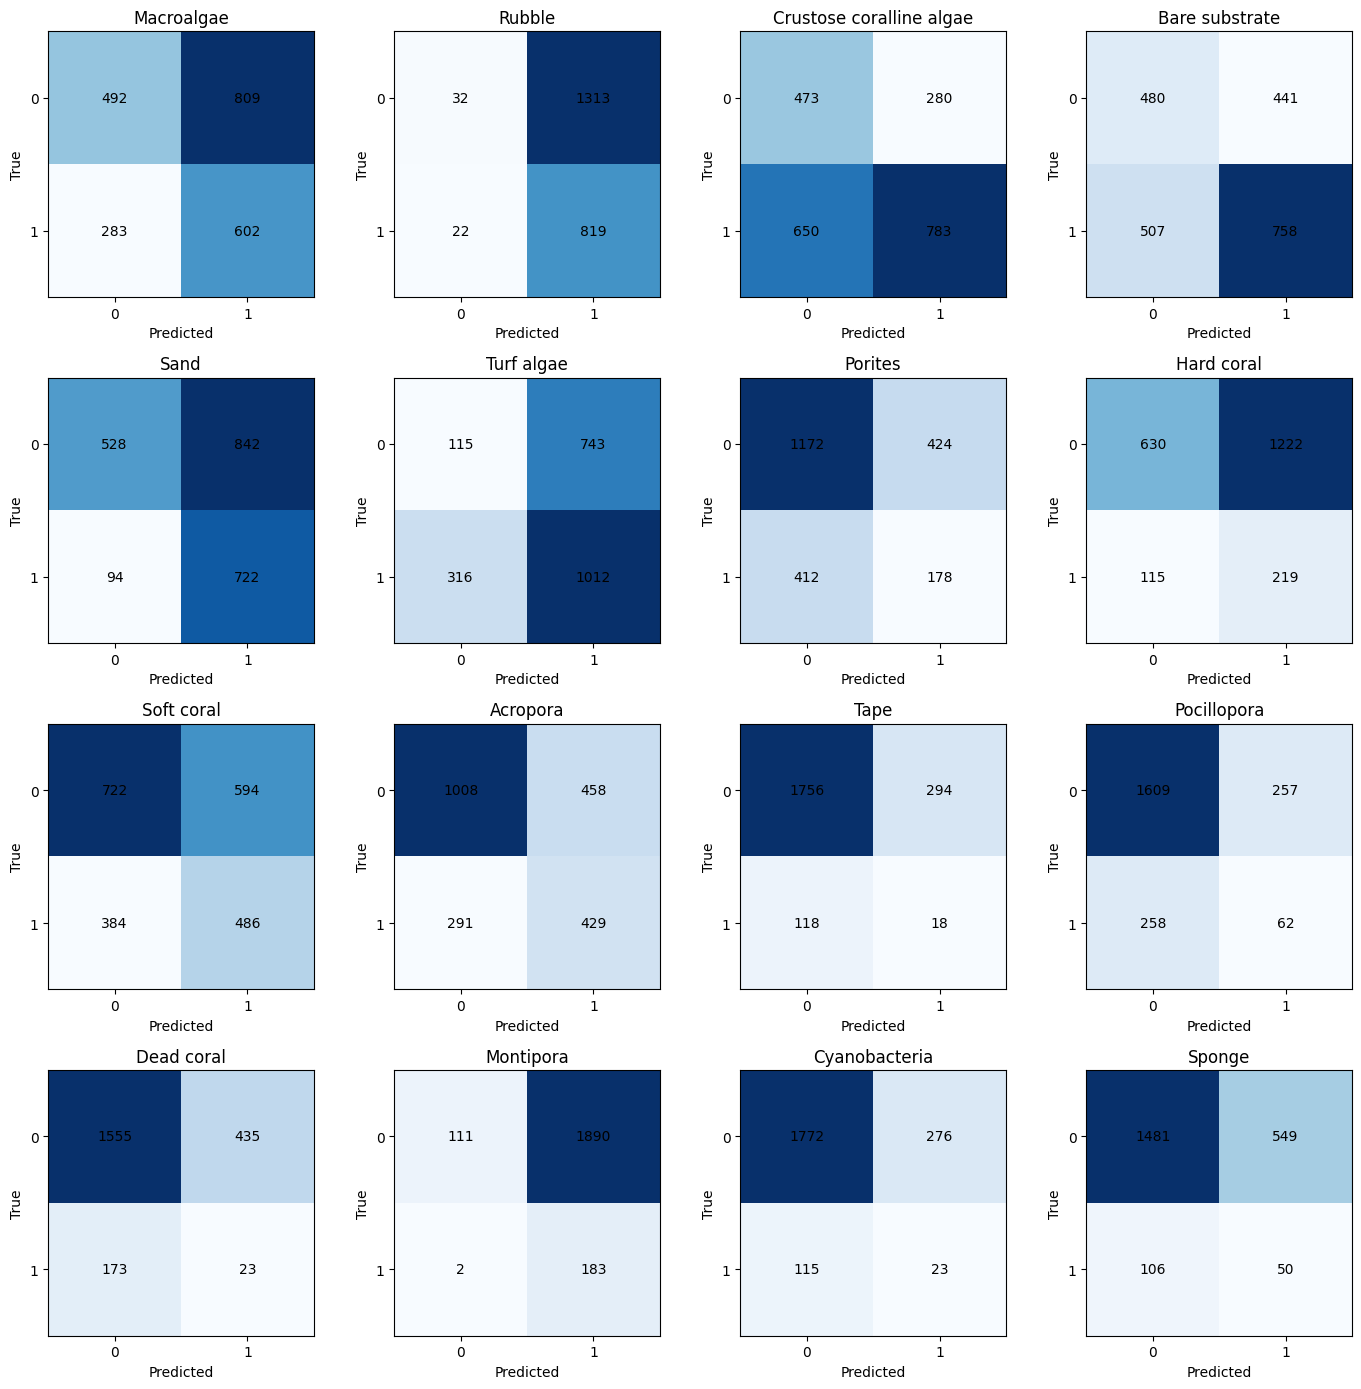

In [72]:
# Visualize Confusion Matrices
plot_confusion_grid(preds, test_targets, class_names)

### ROC Curves

In [73]:
def plot_roc_auc_grid(probs, targets, class_names):
    n_classes = len(class_names)
    cols = 4
    rows = int(n_classes/cols)

    fig, axes = plt.subplots(rows, cols, figsize=(14, 14))
    axes = axes.flatten()

    for i, cls in enumerate(class_names):
        y_true = targets[:, i]
        y_score = probs[:, i]

        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc_value = auc(fpr, tpr)

        ax = axes[i]
        ax.plot(fpr, tpr, label=f"AUC={roc_auc_value:.3f}")
        ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
        ax.set_title(cls)
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.legend()

    plt.tight_layout()
    plt.show()

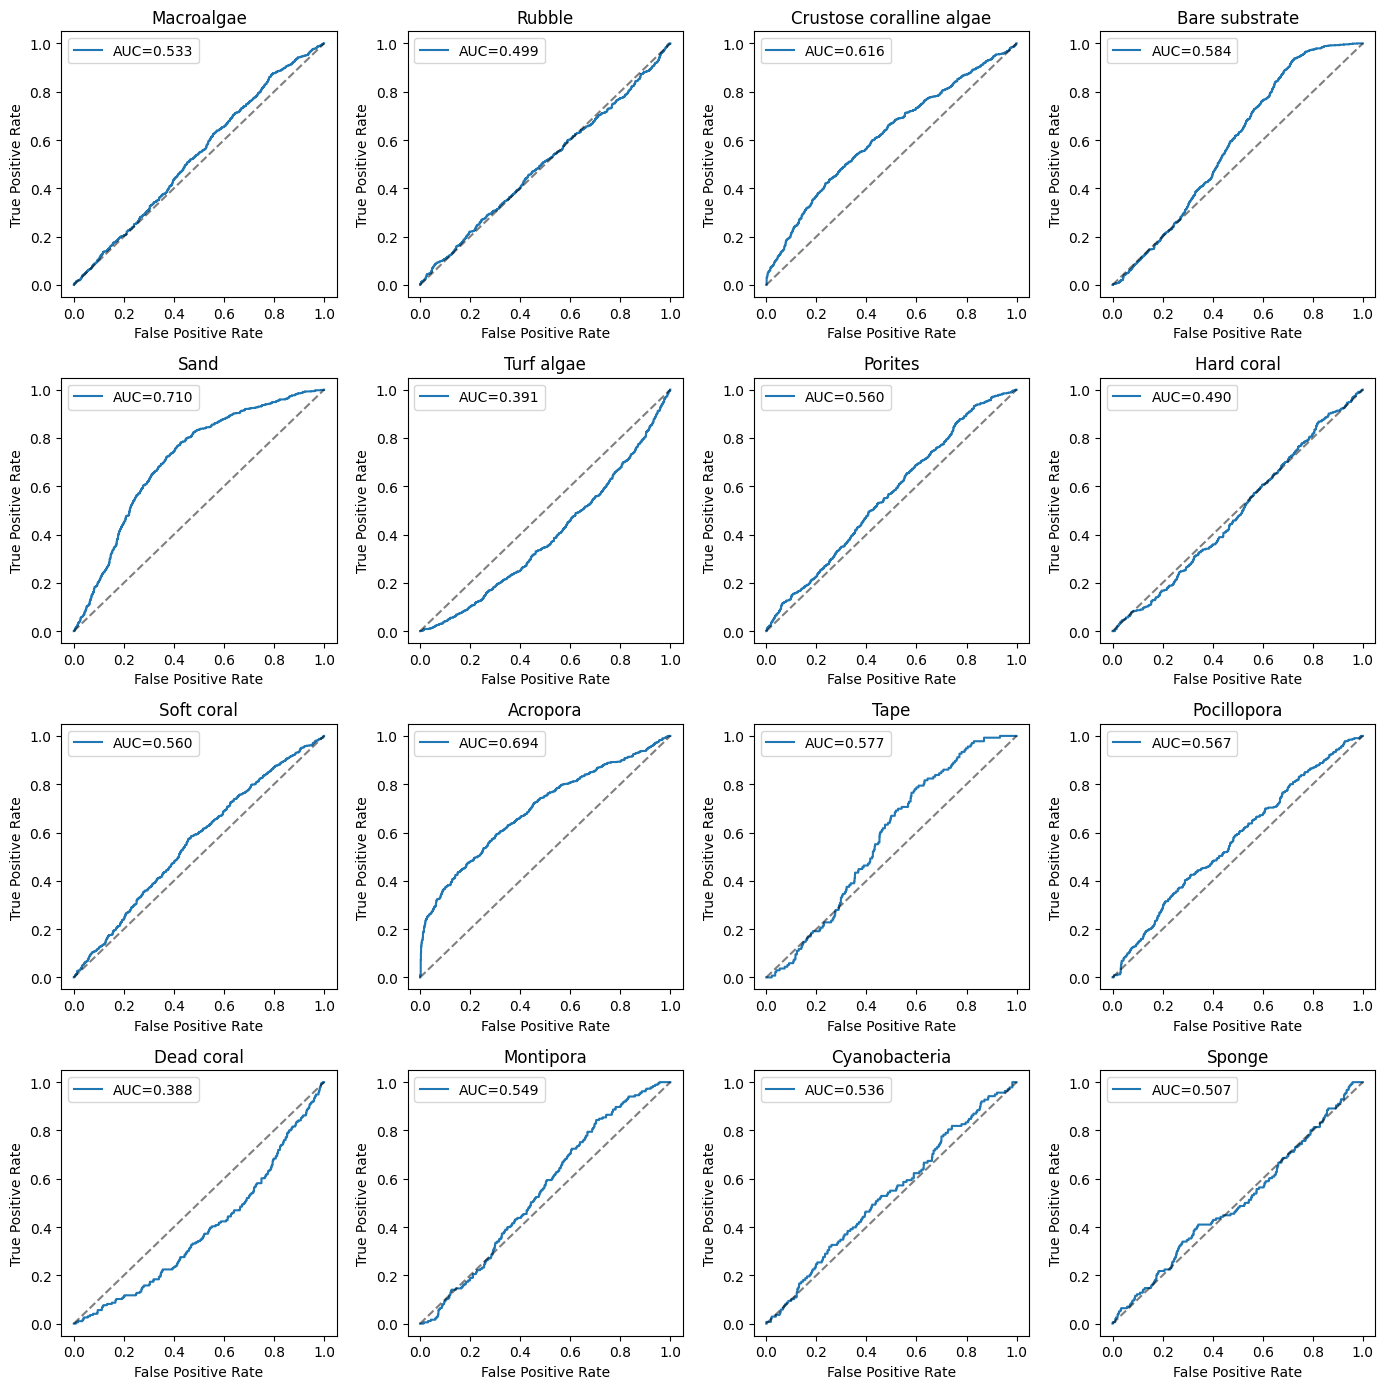

In [74]:
# Plot ROC Curves for all labels
plot_roc_auc_grid(test_probs, test_targets, class_names)

### PR Curves

In [75]:
def plot_pr_auc_grid(probs, targets, class_names):
    n_classes = len(class_names)
    cols = 4
    rows = int(n_classes/cols)

    fig, axes = plt.subplots(rows, cols, figsize=(14, 14))
    axes = axes.flatten()

    for i, cls in enumerate(class_names):
        y_true = targets[:, i]
        y_score = probs[:, i]

        precision, recall, _ = precision_recall_curve(y_true, y_score)
        pr_auc_value = auc(recall, precision)

        ax = axes[i]
        ax.plot(recall, precision, label=f"AP={pr_auc_value:.3f}")
        ax.set_title(cls)
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.legend()

    plt.tight_layout()
    plt.show()

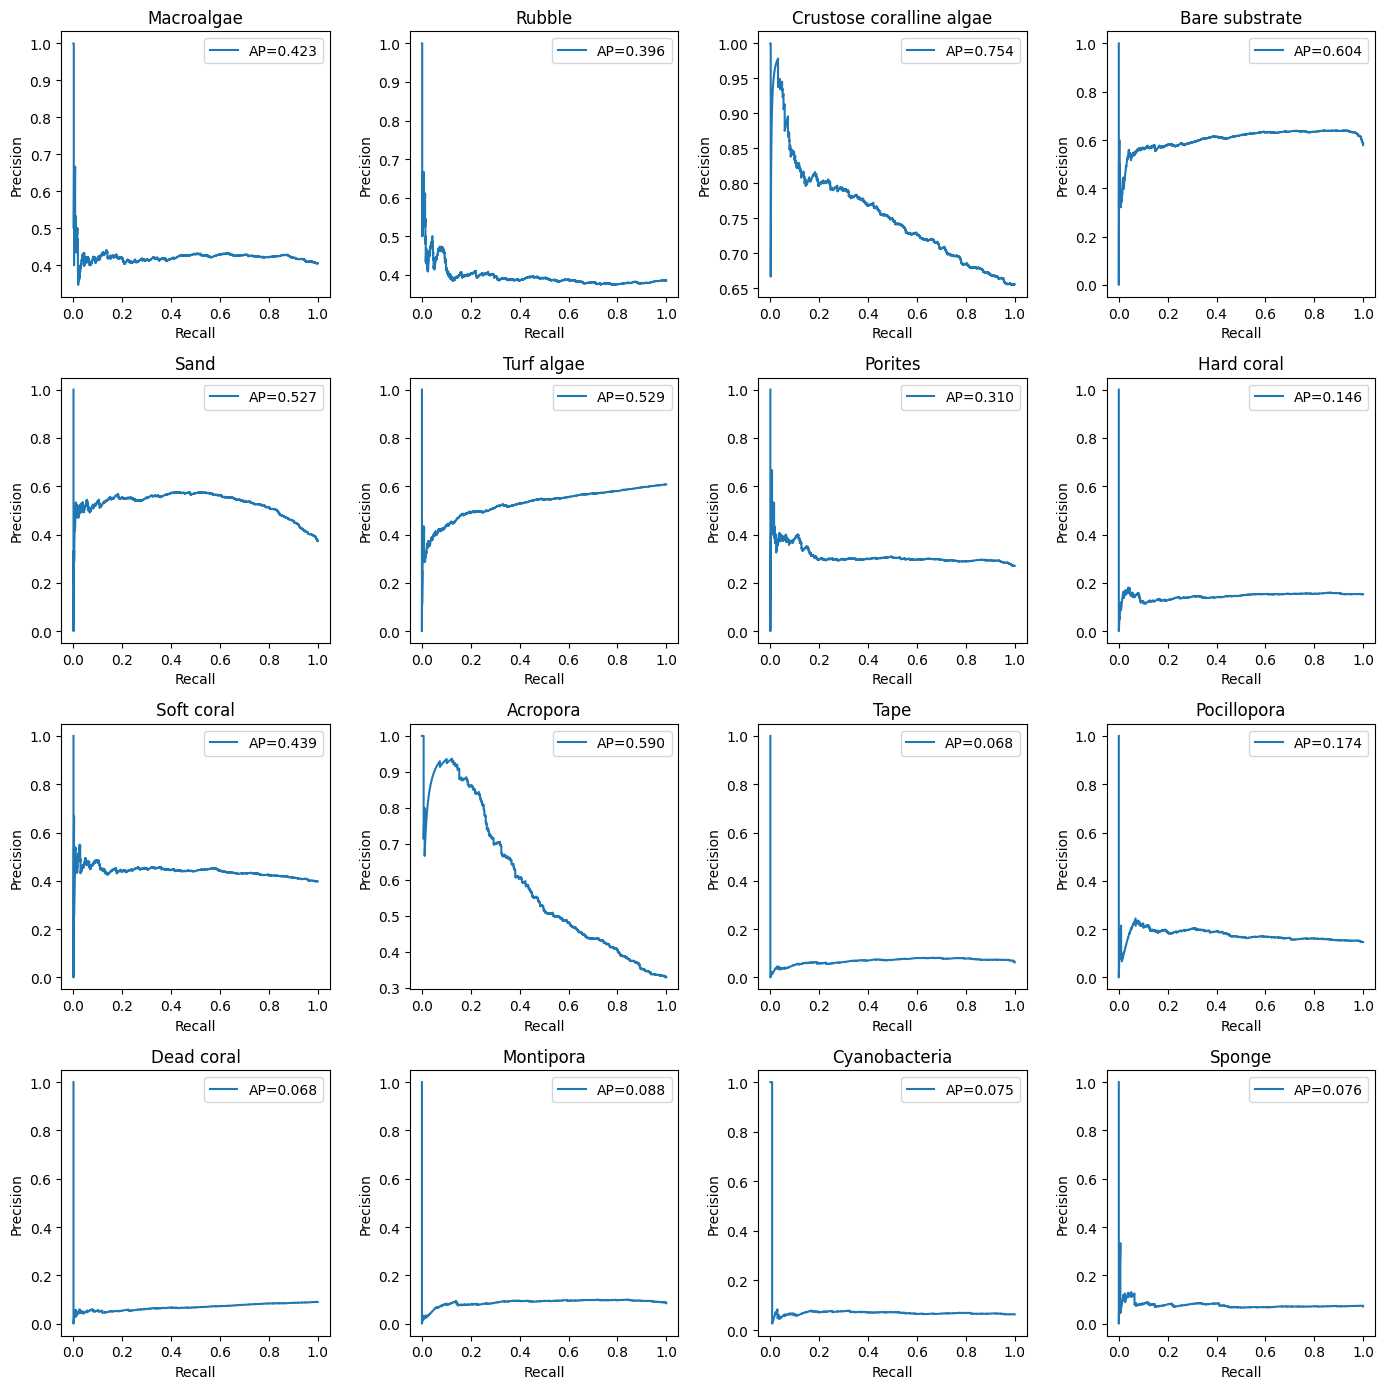

In [76]:
# Plot PR Curves for all labels
plot_pr_auc_grid(test_probs, test_targets, class_names)